In [72]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
pd.set_option('display.max_columns', None)
import sys
from pathlib import Path

# Move from notebooks/ → project root
project_root = Path().resolve().parent

# Add it to Python path
sys.path.append(str(project_root))


In [2]:
 # Plot settings
plt.rcParams["figure.figsize"] = (12, 6)
sns.set(style="whitegrid")

raw = "../data/raw"

In [35]:
# Load all datasets

sales = pd.read_csv(f"{raw}/sunnybest_sales.csv", parse_dates=["date"])
products = pd.read_csv(f"{raw}/sunnybest_products.csv")
stores = pd.read_csv(f"{raw}/sunnybest_stores.csv")
calendar = pd.read_csv(f"{raw}/sunnybest_calendar.csv", parse_dates=["date"])
promos = pd.read_csv(f"{raw}/sunnybest_promotions.csv", parse_dates=["date"])
weather = pd.read_csv(f"{raw}/sunnybest_weather.csv", parse_dates=["date"])
inventory = pd.read_csv(f"{raw}/sunnybest_inventory.csv", parse_dates=["date"])

# 🆕 New datasets
customer_activity = pd.read_csv(f"{raw}/sunnybest_customer_activity.csv", parse_dates=["date"])
store_operations = pd.read_csv(f"{raw}/sunnybest_store_operations.csv", parse_dates=["date"])
policy_regimes = pd.read_csv(f"{raw}/sunnybest_policy_regimes.csv", parse_dates=["start_date", "end_date"])
restriction_events = pd.read_csv(f"{raw}/sunnybest_restriction_events.csv", parse_dates=["date"])

/var/folders/rt/0zxshr9s4g713_r6y5sjpqk80000gn/T/ipykernel_58080/49380473.py:3: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  sales = pd.read_csv(f"{raw}/sunnybest_sales.csv", parse_dates=["date"])


In [36]:
stores.head()

,store_id,store_name,city,area,region,store_type,store_size
0,1,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large
1,2,SunnyBest Ekpoma,Ekpoma,Esan West,Edo Central,High Street,Medium
2,3,SunnyBest Auchi,Auchi,Etsako West,Edo North,High Street,Medium
3,4,SunnyBest Irrua,Irrua,Esan Central,Edo Central,Plaza,Small
4,5,SunnyBest Igueben,Igueben,Igueben,Edo Central,High Street,Small


In [37]:
products.head()

,product_id,product_name,category,brand,regular_price,cost_price,is_seasonal,warranty_months
0,1001,LG Televisions Model-120,Televisions,LG,445838,332772,1,6
1,1002,Tecno Mobile Model-199,Mobile Phones,Tecno,500410,346208,1,6
2,1003,Tecno Mobile Model-905,Mobile Phones,Tecno,399365,244124,1,12
3,1004,Infinix Mobile Model-121,Mobile Phones,Infinix,305796,221242,1,12
4,1005,Samsung Mobile Model-781,Mobile Phones,Samsung,462752,326219,1,24


In [39]:
products.is_seasonal.value_counts()

is_seasonal
1    61
0    59
Name: count, dtype: int64

In [41]:
products.shape

(120, 8)

In [42]:
calendar

,date,year,month,day,day_of_week,day_of_week_num,week_of_year,is_weekend,is_holiday,is_payday,season,is_black_friday_period
0,2021-01-01,2021,1,1,Friday,4,53,False,True,False,Dry,False
1,2021-01-02,2021,1,2,Saturday,5,53,True,False,False,Dry,False
2,2021-01-03,2021,1,3,Sunday,6,53,True,False,False,Dry,False
3,2021-01-04,2021,1,4,Monday,0,1,False,False,False,Dry,False
4,2021-01-05,2021,1,5,Tuesday,1,1,False,False,False,Dry,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1456,2024-12-27,2024,12,27,Friday,4,52,False,False,False,Dry,False
1457,2024-12-28,2024,12,28,Saturday,5,52,True,False,False,Dry,False
1458,2024-12-29,2024,12,29,Sunday,6,52,True,False,False,Dry,False
1459,2024-12-30,2024,12,30,Monday,0,1,False,False,False,Dry,False


In [45]:
calendar.nunique()

date                      1461
year                         4
month                       12
day                         31
day_of_week                  7
day_of_week_num              7
week_of_year                53
is_weekend                   2
is_holiday                   2
is_payday                    2
season                       3
is_black_friday_period       2
dtype: int64

In [47]:
calendar.season.value_counts()

season
Early Rainy    612
Dry            481
Late Rainy     368
Name: count, dtype: int64

In [4]:
df = (
    sales
    .merge(products, on="product_id", how="left", suffixes=("", "_product"))
    .merge(stores, on="store_id", how="left", suffixes=("", "_store"))
    .merge(calendar, on="date", how="left", suffixes=("", "_cal"))
    .merge(weather, on=["date", "city"], how="left", suffixes=("", "_weather"))
    .merge(promos, on=["date", "store_id", "product_id"], how="left", suffixes=("", "_promo"))
)

print(df.shape)
df.head()


(1227240, 43)


,date,store_id,product_id,units_sold,price,regular_price,discount_pct,promo_flag,promo_type,revenue,starting_inventory,ending_inventory,stockout_occurred,city,store_size,category,product_name,category_product,brand,regular_price_product,cost_price,is_seasonal,warranty_months,store_name,city_store,area,region,store_type,store_size_store,year,month,day,day_of_week,is_weekend,is_holiday,is_payday,season,temperature_c,rainfall_mm,weather_condition,promo_type_promo,discount_pct_promo,promo_flag_promo
0,2021-01-01,1,1001,0,445838.0,445838,0,0,NaN,0.0,1,1,0,Benin,Large,Televisions,LG Televisions Model-120,Televisions,LG,445838,332772,1,6,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2021,1,1,Friday,False,True,False,Dry,30.6,3.7,Rainy,NaN,NaN,NaN
1,2021-01-01,1,1002,2,500410.0,500410,0,0,NaN,1000820.0,6,4,0,Benin,Large,Mobile Phones,Tecno Mobile Model-199,Mobile Phones,Tecno,500410,346208,1,6,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2021,1,1,Friday,False,True,False,Dry,30.6,3.7,Rainy,NaN,NaN,NaN
2,2021-01-01,1,1003,2,399365.0,399365,0,0,NaN,798730.0,2,0,1,Benin,Large,Mobile Phones,Tecno Mobile Model-905,Mobile Phones,Tecno,399365,244124,1,12,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2021,1,1,Friday,False,True,False,Dry,30.6,3.7,Rainy,NaN,NaN,NaN
3,2021-01-01,1,1004,4,305796.0,305796,0,0,NaN,1223184.0,10,6,0,Benin,Large,Mobile Phones,Infinix Mobile Model-121,Mobile Phones,Infinix,305796,221242,1,12,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2021,1,1,Friday,False,True,False,Dry,30.6,3.7,Rainy,NaN,NaN,NaN
4,2021-01-01,1,1005,5,462752.0,462752,0,0,NaN,2313760.0,28,23,0,Benin,Large,Mobile Phones,Samsung Mobile Model-781,Mobile Phones,Samsung,462752,326219,1,24,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2021,1,1,Friday,False,True,False,Dry,30.6,3.7,Rainy,NaN,NaN,NaN


## Stores Data Overview & Business Context

The stores dataset provides **static reference information** about each physical retail location.  
Each row represents **one store**, describing its geographical location and operational scale.  
This data does not change daily and is used to **add contextual information** to sales records rather than to record sales events themselves.

---

### Store Data Grain

- **One row = one store**
- The dataset grows only when:
  - a new store opens, or  
  - store attributes are updated

---

### Key Store Columns & Meanings

| Column | Business Meaning |
|------|------------------|
| store_id | Unique identifier for a physical retail store |
| city | City in which the store is located |
| store_size | Classification of store scale (e.g. Small, Medium, Large), reflecting capacity and expected footfall |

---

### How This Data Is Used

Store attributes are **joined onto the sales data** to help explain differences in demand and performance across locations.  
For example, larger stores or stores in certain cities may consistently sell higher volumes than others.

---

### Important Note

The stores dataset **does not record sales**.  
It provides **context** that helps interpret sales outcomes observed in the daily sales dataset.


In [5]:
df.head()

,date,store_id,product_id,units_sold,price,regular_price,discount_pct,promo_flag,promo_type,revenue,starting_inventory,ending_inventory,stockout_occurred,city,store_size,category,product_name,category_product,brand,regular_price_product,cost_price,is_seasonal,warranty_months,store_name,city_store,area,region,store_type,store_size_store,year,month,day,day_of_week,is_weekend,is_holiday,is_payday,season,temperature_c,rainfall_mm,weather_condition,promo_type_promo,discount_pct_promo,promo_flag_promo
0,2021-01-01,1,1001,0,445838.0,445838,0,0,NaN,0.0,1,1,0,Benin,Large,Televisions,LG Televisions Model-120,Televisions,LG,445838,332772,1,6,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2021,1,1,Friday,False,True,False,Dry,30.6,3.7,Rainy,NaN,NaN,NaN
1,2021-01-01,1,1002,2,500410.0,500410,0,0,NaN,1000820.0,6,4,0,Benin,Large,Mobile Phones,Tecno Mobile Model-199,Mobile Phones,Tecno,500410,346208,1,6,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2021,1,1,Friday,False,True,False,Dry,30.6,3.7,Rainy,NaN,NaN,NaN
2,2021-01-01,1,1003,2,399365.0,399365,0,0,NaN,798730.0,2,0,1,Benin,Large,Mobile Phones,Tecno Mobile Model-905,Mobile Phones,Tecno,399365,244124,1,12,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2021,1,1,Friday,False,True,False,Dry,30.6,3.7,Rainy,NaN,NaN,NaN
3,2021-01-01,1,1004,4,305796.0,305796,0,0,NaN,1223184.0,10,6,0,Benin,Large,Mobile Phones,Infinix Mobile Model-121,Mobile Phones,Infinix,305796,221242,1,12,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2021,1,1,Friday,False,True,False,Dry,30.6,3.7,Rainy,NaN,NaN,NaN
4,2021-01-01,1,1005,5,462752.0,462752,0,0,NaN,2313760.0,28,23,0,Benin,Large,Mobile Phones,Samsung Mobile Model-781,Mobile Phones,Samsung,462752,326219,1,24,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2021,1,1,Friday,False,True,False,Dry,30.6,3.7,Rainy,NaN,NaN,NaN


In [6]:
df.head()

,date,store_id,product_id,units_sold,price,regular_price,discount_pct,promo_flag,promo_type,revenue,starting_inventory,ending_inventory,stockout_occurred,city,store_size,category,product_name,category_product,brand,regular_price_product,cost_price,is_seasonal,warranty_months,store_name,city_store,area,region,store_type,store_size_store,year,month,day,day_of_week,is_weekend,is_holiday,is_payday,season,temperature_c,rainfall_mm,weather_condition,promo_type_promo,discount_pct_promo,promo_flag_promo
0,2021-01-01,1,1001,0,445838.0,445838,0,0,NaN,0.0,1,1,0,Benin,Large,Televisions,LG Televisions Model-120,Televisions,LG,445838,332772,1,6,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2021,1,1,Friday,False,True,False,Dry,30.6,3.7,Rainy,NaN,NaN,NaN
1,2021-01-01,1,1002,2,500410.0,500410,0,0,NaN,1000820.0,6,4,0,Benin,Large,Mobile Phones,Tecno Mobile Model-199,Mobile Phones,Tecno,500410,346208,1,6,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2021,1,1,Friday,False,True,False,Dry,30.6,3.7,Rainy,NaN,NaN,NaN
2,2021-01-01,1,1003,2,399365.0,399365,0,0,NaN,798730.0,2,0,1,Benin,Large,Mobile Phones,Tecno Mobile Model-905,Mobile Phones,Tecno,399365,244124,1,12,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2021,1,1,Friday,False,True,False,Dry,30.6,3.7,Rainy,NaN,NaN,NaN
3,2021-01-01,1,1004,4,305796.0,305796,0,0,NaN,1223184.0,10,6,0,Benin,Large,Mobile Phones,Infinix Mobile Model-121,Mobile Phones,Infinix,305796,221242,1,12,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2021,1,1,Friday,False,True,False,Dry,30.6,3.7,Rainy,NaN,NaN,NaN
4,2021-01-01,1,1005,5,462752.0,462752,0,0,NaN,2313760.0,28,23,0,Benin,Large,Mobile Phones,Samsung Mobile Model-781,Mobile Phones,Samsung,462752,326219,1,24,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2021,1,1,Friday,False,True,False,Dry,30.6,3.7,Rainy,NaN,NaN,NaN


In [7]:
df.shape

(1227240, 43)

In [8]:
df.describe(include='all')

,date,store_id,product_id,units_sold,price,regular_price,discount_pct,promo_flag,promo_type,revenue,starting_inventory,ending_inventory,stockout_occurred,city,store_size,category,product_name,category_product,brand,regular_price_product,cost_price,is_seasonal,warranty_months,store_name,city_store,area,region,store_type,store_size_store,year,month,day,day_of_week,is_weekend,is_holiday,is_payday,season,temperature_c,rainfall_mm,weather_condition,promo_type_promo,discount_pct_promo,promo_flag_promo
count,1227240,1.227240e+06,1.227240e+06,1.227240e+06,1.227240e+06,1.227240e+06,1.227240e+06,1.227240e+06,292,1.227240e+06,1.227240e+06,1.227240e+06,1.227240e+06,1227240,1227240,1227240,1227240,1227240,1227240,1.227240e+06,1.227240e+06,1.227240e+06,1.227240e+06,1227240,1227240,1227240,1227240,1227240,1227240,1.227240e+06,1.227240e+06,1.227240e+06,1227240,1227240,1227240,1227240,1227240,1.227240e+06,1.227240e+06,1227240,292,292.000000,292.0
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,7,3,9,120,9,26,NaN,NaN,NaN,NaN,7,7,6,3,3,3,NaN,NaN,NaN,7,2,2,2,3,NaN,NaN,3,4,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Discount,NaN,NaN,NaN,NaN,Benin,Small,Mobile Phones,LG Televisions Model-120,Mobile Phones,LG,NaN,NaN,NaN,NaN,SunnyBest Benin Main,Benin,Esan West,Edo Central,High Street,Small,NaN,NaN,NaN,Friday,False,False,False,Early Rainy,NaN,NaN,Rainy,Discount,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,171,NaN,NaN,NaN,NaN,175320,701280,235221,10227,235221,153405,NaN,NaN,NaN,NaN,175320,175320,350640,701280,701280,701280,NaN,NaN,NaN,175560,876120,1210440,1186920,514080,NaN,NaN,505080,171,NaN,NaN
mean,2022-12-31 23:59:59.999999744,4.000000e+00,1.060500e+03,2.435828e+00,3.124509e+05,3.124595e+05,2.978228e-03,2.379323e-04,NaN,2.561325e+05,8.220214e+00,5.784386e+00,4.094798e-02,NaN,NaN,NaN,NaN,NaN,NaN,3.124595e+05,2.177207e+05,5.083333e-01,1.350000e+01,NaN,NaN,NaN,NaN,NaN,NaN,2.022501e+03,6.522930e+00,1.572964e+01,NaN,NaN,NaN,NaN,NaN,2.849883e+01,3.412927e+00,NaN,NaN,12.517123,1.0
min,2021-01-01 00:00:00,1.000000e+00,1.001000e+03,0.000000e+00,6.900000e+02,6.900000e+02,0.000000e+00,0.000000e+00,NaN,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,6.900000e+02,4.560000e+02,0.000000e+00,6.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,2.021000e+03,1.000000e+00,1.000000e+00,NaN,NaN,NaN,NaN,NaN,2.210000e+01,0.000000e+00,NaN,NaN,0.000000,1.0
25%,2022-01-01 00:00:00,2.000000e+00,1.030750e+03,0.000000e+00,6.401200e+04,6.590800e+04,0.000000e+00,0.000000e+00,NaN,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,6.590800e+04,4.568850e+04,0.000000e+00,6.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,2.022000e+03,4.000000e+00,8.000000e+00,NaN,NaN,NaN,NaN,NaN,2.720000e+01,2.000000e-01,NaN,NaN,0.000000,1.0
50%,2023-01-01 00:00:00,4.000000e+00,1.060500e+03,1.000000e+00,2.514150e+05,2.521605e+05,0.000000e+00,0.000000e+00,NaN,1.126680e+05,2.000000e+00,1.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,2.521605e+05,1.772030e+05,1.000000e+00,1.200000e+01,NaN,NaN,NaN,NaN,NaN,NaN,2.023000e+03,7.000000e+00,1.600000e+01,NaN,NaN,NaN,NaN,NaN,2.850000e+01,2.200000e+00,NaN,NaN,10.000000,1.0
75%,2024-01-01 00:00:00,6.000000e+00,1.090250e+03,2.000000e+00,5.041590e+05,5.065822e+05,0.000000e+00,0.000000e+00,NaN,4.108960e+05,7.000000e+00,4.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,5.065822e+05,3.351362e+05,1.000000e+00,2.400000e+01,NaN,NaN,NaN,NaN,NaN,NaN,2.024000e+03,1.000000e+01,2.300000e+01,NaN,NaN,NaN,NaN,NaN,2.980000e+01,5.200000e+00,NaN,NaN,20.000000,1.0
max,2024-12-31 00:00:00,7.000000e+00,1.120000e+03,1.150000e+02,8.796500e+05,8.796500e+05,3.000000e+01,1.000000e+00,NaN,5.090272e+06,4.440000e+02,3.720000e+02,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,8.796500e+05,6.847270e+05,1.000000e+00,2.400000e+01,NaN,NaN,NaN,NaN,NaN,NaN,2.024000e+03,1.200000e+01,3.100000e+01,NaN,NaN,NaN,NaN,NaN,3.520000e+01,2.130000e+01,NaN,NaN,30.000000,1.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1227240 entries, 0 to 1227239
Data columns (total 43 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   date                   1227240 non-null  datetime64[ns]
 1   store_id               1227240 non-null  int64         
 2   product_id             1227240 non-null  int64         
 3   units_sold             1227240 non-null  int64         
 4   price                  1227240 non-null  float64       
 5   regular_price          1227240 non-null  int64         
 6   discount_pct           1227240 non-null  int64         
 7   promo_flag             1227240 non-null  int64         
 8   promo_type             292 non-null      object        
 9   revenue                1227240 non-null  float64       
 10  starting_inventory     1227240 non-null  int64         
 11  ending_inventory       1227240 non-null  int64         
 12  stockout_occurred      12272

- We are planning inventory for the next 4 weeks. Can you forecast weekly sales for each store so we know how much stock to order?

In [10]:
df.head()

,date,store_id,product_id,units_sold,price,regular_price,discount_pct,promo_flag,promo_type,revenue,starting_inventory,ending_inventory,stockout_occurred,city,store_size,category,product_name,category_product,brand,regular_price_product,cost_price,is_seasonal,warranty_months,store_name,city_store,area,region,store_type,store_size_store,year,month,day,day_of_week,is_weekend,is_holiday,is_payday,season,temperature_c,rainfall_mm,weather_condition,promo_type_promo,discount_pct_promo,promo_flag_promo
0,2021-01-01,1,1001,0,445838.0,445838,0,0,NaN,0.0,1,1,0,Benin,Large,Televisions,LG Televisions Model-120,Televisions,LG,445838,332772,1,6,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2021,1,1,Friday,False,True,False,Dry,30.6,3.7,Rainy,NaN,NaN,NaN
1,2021-01-01,1,1002,2,500410.0,500410,0,0,NaN,1000820.0,6,4,0,Benin,Large,Mobile Phones,Tecno Mobile Model-199,Mobile Phones,Tecno,500410,346208,1,6,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2021,1,1,Friday,False,True,False,Dry,30.6,3.7,Rainy,NaN,NaN,NaN
2,2021-01-01,1,1003,2,399365.0,399365,0,0,NaN,798730.0,2,0,1,Benin,Large,Mobile Phones,Tecno Mobile Model-905,Mobile Phones,Tecno,399365,244124,1,12,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2021,1,1,Friday,False,True,False,Dry,30.6,3.7,Rainy,NaN,NaN,NaN
3,2021-01-01,1,1004,4,305796.0,305796,0,0,NaN,1223184.0,10,6,0,Benin,Large,Mobile Phones,Infinix Mobile Model-121,Mobile Phones,Infinix,305796,221242,1,12,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2021,1,1,Friday,False,True,False,Dry,30.6,3.7,Rainy,NaN,NaN,NaN
4,2021-01-01,1,1005,5,462752.0,462752,0,0,NaN,2313760.0,28,23,0,Benin,Large,Mobile Phones,Samsung Mobile Model-781,Mobile Phones,Samsung,462752,326219,1,24,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2021,1,1,Friday,False,True,False,Dry,30.6,3.7,Rainy,NaN,NaN,NaN


In [12]:
df["promo_type"]

0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
          ... 
1227235    NaN
1227236    NaN
1227237    NaN
1227238    NaN
1227239    NaN
Name: promo_type, Length: 1227240, dtype: object

In [13]:
df_filtered = df[df["promo_type"].notna()]

In [14]:
df_filtered

,date,store_id,product_id,units_sold,price,regular_price,discount_pct,promo_flag,promo_type,revenue,starting_inventory,ending_inventory,stockout_occurred,city,store_size,category,product_name,category_product,brand,regular_price_product,cost_price,is_seasonal,warranty_months,store_name,city_store,area,region,store_type,store_size_store,year,month,day,day_of_week,is_weekend,is_holiday,is_payday,season,temperature_c,rainfall_mm,weather_condition,promo_type_promo,discount_pct_promo,promo_flag_promo
71409,2021-03-27,1,1010,0,722843.00,722843,0,1,Bundle,0.00,1,1,0,Benin,Large,Laptops & Computers,Acer Laptops Model-134,Laptops & Computers,Acer,722843,505292,0,24,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2021,3,27,Saturday,True,False,False,Early Rainy,29.3,1.8,Cloudy,Bundle,0.0,1.0
71454,2021-03-27,1,1055,1,839944.00,839944,0,1,Bundle,839944.00,3,2,0,Benin,Large,Laptops & Computers,Dell Laptops Model-669,Laptops & Computers,Dell,839944,570270,0,12,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2021,3,27,Saturday,True,False,False,Early Rainy,29.3,1.8,Cloudy,Bundle,0.0,1.0
71538,2021-03-27,2,1019,1,328325.40,364806,10,1,Discount,328325.40,3,2,0,Ekpoma,Medium,Televisions,LG Televisions Model-132,Televisions,LG,364806,280903,1,12,SunnyBest Ekpoma,Ekpoma,Esan West,Edo Central,High Street,Medium,2021,3,27,Saturday,True,False,False,Early Rainy,28.3,2.1,Cloudy,Discount,10.0,1.0
71703,2021-03-27,3,1064,1,401451.00,401451,0,1,Free Accessory,401451.00,2,1,0,Auchi,Medium,Laptops & Computers,Asus Laptops Model-202,Laptops & Computers,Asus,401451,258198,0,6,SunnyBest Auchi,Auchi,Etsako West,Edo North,High Street,Medium,2021,3,27,Saturday,True,False,False,Early Rainy,30.4,1.2,Cloudy,Free Accessory,0.0,1.0
71713,2021-03-27,3,1074,0,584963.00,584963,0,1,Free Accessory,0.00,1,1,0,Auchi,Medium,Refrigerators,Haier Thermocool Refrigerators Model-456,Refrigerators,Haier Thermocool,584963,371241,1,12,SunnyBest Auchi,Auchi,Etsako West,Edo North,High Street,Medium,2021,3,27,Saturday,True,False,False,Early Rainy,30.4,1.2,Cloudy,Free Accessory,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1221478,2024-12-25,1,1119,2,625245.35,658153,5,1,Discount,1250490.70,4,2,0,Benin,Large,Laptops & Computers,Dell Laptops Model-870,Laptops & Computers,Dell,658153,463380,0,12,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2024,12,25,Wednesday,False,True,True,Dry,28.9,1.4,Cloudy,Discount,5.0,1.0
1221787,2024-12-25,4,1068,4,304283.70,338093,10,1,Discount,1217134.80,10,6,0,Irrua,Small,Mobile Phones,Itel Mobile Model-740,Mobile Phones,Itel,338093,259383,1,6,SunnyBest Irrua,Irrua,Esan Central,Edo Central,Plaza,Small,2024,12,25,Wednesday,False,True,True,Dry,26.1,0.0,Sunny,Discount,10.0,1.0
1221865,2024-12-25,5,1026,3,49885.65,58689,15,1,Discount,149656.95,9,6,0,Igueben,Small,Small Appliances,Philips Small Model-745,Small Appliances,Philips,58689,44698,0,6,SunnyBest Igueben,Igueben,Igueben,Edo Central,High Street,Small,2024,12,25,Wednesday,False,True,True,Dry,26.1,2.7,Cloudy,Discount,15.0,1.0
1222095,2024-12-25,7,1016,1,54976.00,54976,0,1,Free Accessory,54976.00,4,3,0,Ogwa,Small,Small Appliances,Binatone Small Model-164,Small Appliances,Binatone,54976,36243,0,6,SunnyBest Ogwa,Ogwa,Esan West,Edo Central,High Street,Small,2024,12,25,Wednesday,False,True,True,Dry,27.3,0.5,Cloudy,Free Accessory,0.0,1.0


In [ ]:
['date', 'store_id', 'product_id', 'units_sold', 'price',
       'regular_price', 'discount_pct', 'promo_flag', 'promo_type', 'revenue',
       'starting_inventory', 'ending_inventory', 'stockout_occurred', 'city',
       'store_size', 'category', 'product_name', 'category_product', 'brand',
       'regular_price_product', 'cost_price', 'is_seasonal', 'warranty_months',
       'store_name', 'city_store', 'area', 'region', 'store_type',
       'store_size_store', 'year', 'month', 'day', 'day_of_week', 'is_weekend',
       'is_holiday', 'is_payday', 'season', 'temperature_c', 'rainfall_mm',
       'weather_condition', 'promo_type_promo', 'discount_pct_promo',
       'promo_flag_promo']

<Axes: >

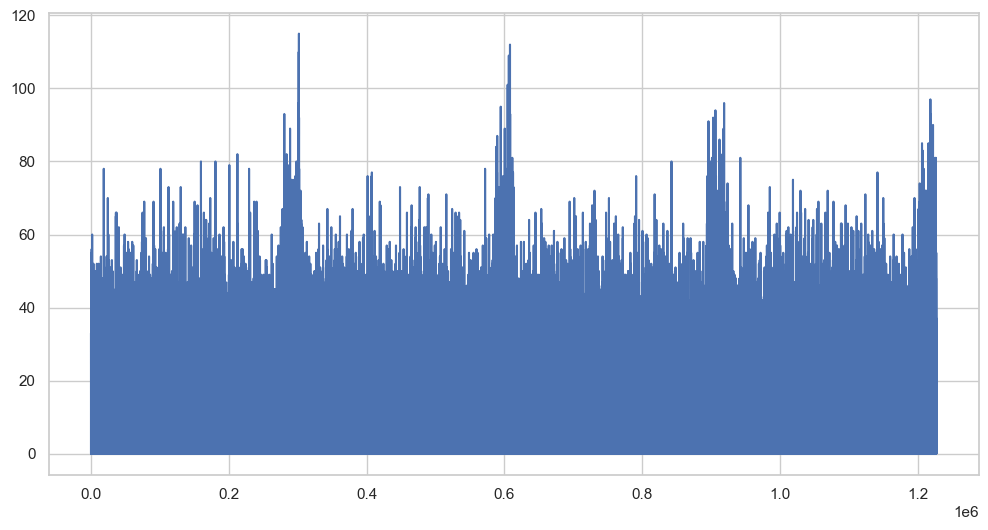

In [19]:
df['units_sold'].plot()

In [22]:
import pandas as pd

# Load your dataset
#df = pd.read_csv("data/processed/your_dataset.csv")

# Take random sample (e.g. 100 rows)
sample_df = df.sample(n=100, random_state=42)

sample_df

,date,store_id,product_id,units_sold,price,regular_price,discount_pct,promo_flag,promo_type,revenue,starting_inventory,ending_inventory,stockout_occurred,city,store_size,category,product_name,category_product,brand,regular_price_product,cost_price,is_seasonal,warranty_months,store_name,city_store,area,region,store_type,store_size_store,year,month,day,day_of_week,is_weekend,is_holiday,is_payday,season,temperature_c,rainfall_mm,weather_condition,promo_type_promo,discount_pct_promo,promo_flag_promo
495376,2022-08-13,6,1017,3,190151.0,190151,0,0,NaN,570453.0,10,7,0,Agenebode,Small,Mobile Phones,Samsung Mobile Model-238,Mobile Phones,Samsung,190151,129108,1,24,SunnyBest Agenebode,Agenebode,Etsako East,Edo North,Plaza,Small,2022,8,13,Saturday,True,False,False,Late Rainy,24.1,2.7,Cloudy,NaN,NaN,NaN
381712,2022-03-31,3,1113,1,82292.0,82292,0,0,NaN,82292.0,3,2,0,Auchi,Medium,Network Devices,TP-Link Network Model-953,Network Devices,TP-Link,82292,61712,0,6,SunnyBest Auchi,Auchi,Etsako West,Edo North,High Street,Medium,2022,3,31,Thursday,False,False,False,Early Rainy,29.7,0.5,Cloudy,NaN,NaN,NaN
338134,2022-02-07,4,1095,1,37556.0,37556,0,0,NaN,37556.0,8,7,0,Irrua,Small,Small Appliances,Binatone Small Model-747,Small Appliances,Binatone,37556,23170,0,24,SunnyBest Irrua,Irrua,Esan Central,Edo Central,Plaza,Small,2022,2,7,Monday,False,False,False,Dry,30.0,2.6,Cloudy,NaN,NaN,NaN
806068,2023-08-18,5,1029,1,378576.0,378576,0,0,NaN,378576.0,1,0,0,Igueben,Small,Laptops & Computers,Lenovo Laptops Model-926,Laptops & Computers,Lenovo,378576,236221,0,24,SunnyBest Igueben,Igueben,Igueben,Edo Central,High Street,Small,2023,8,18,Friday,False,False,False,Late Rainy,27.2,7.0,Rainy,NaN,NaN,NaN
522937,2022-09-15,4,1098,0,548345.0,548345,0,0,NaN,0.0,1,1,0,Irrua,Small,Air Conditioners,Panasonic Air Model-550,Air Conditioners,Panasonic,548345,365225,1,12,SunnyBest Irrua,Irrua,Esan Central,Edo Central,Plaza,Small,2022,9,15,Thursday,False,False,False,Late Rainy,25.8,11.5,Rainy,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340712,2022-02-10,5,1033,2,26556.0,26556,0,0,NaN,53112.0,15,13,0,Igueben,Small,Accessories,Generic Accessories Model-515,Accessories,Generic,26556,18533,0,12,SunnyBest Igueben,Igueben,Igueben,Edo Central,High Street,Small,2022,2,10,Thursday,False,False,False,Dry,27.6,2.6,Cloudy,NaN,NaN,NaN
617089,2023-01-05,5,1050,0,117888.0,117888,0,0,NaN,0.0,4,4,0,Igueben,Small,Network Devices,ZTE Network Model-552,Network Devices,ZTE,117888,84334,0,6,SunnyBest Igueben,Igueben,Igueben,Edo Central,High Street,Small,2023,1,5,Thursday,False,False,False,Dry,29.1,0.7,Cloudy,NaN,NaN,NaN
800717,2023-08-12,2,1078,5,20052.0,20052,0,0,NaN,100260.0,11,6,0,Ekpoma,Medium,Small Appliances,Binatone Small Model-367,Small Appliances,Binatone,20052,14219,0,6,SunnyBest Ekpoma,Ekpoma,Esan West,Edo Central,High Street,Medium,2023,8,12,Saturday,True,False,False,Late Rainy,26.3,4.0,Rainy,NaN,NaN,NaN
608183,2022-12-26,1,1024,1,561357.0,561357,0,0,NaN,561357.0,4,3,0,Benin,Large,Laptops & Computers,Acer Laptops Model-848,Laptops & Computers,Acer,561357,352457,0,24,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large,2022,12,26,Monday,False,True,False,Dry,28.9,0.0,Sunny,NaN,NaN,NaN


<Axes: >

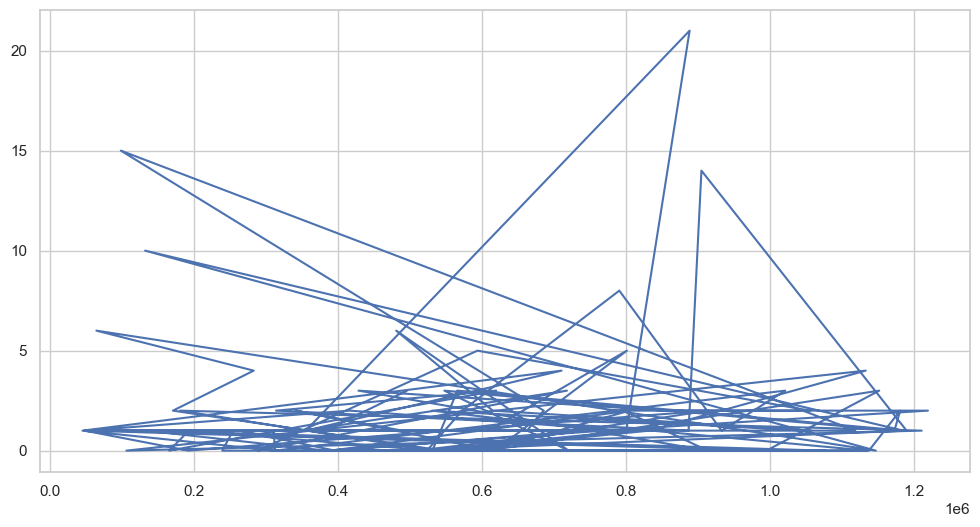

In [23]:
sample_df['units_sold'].plot()

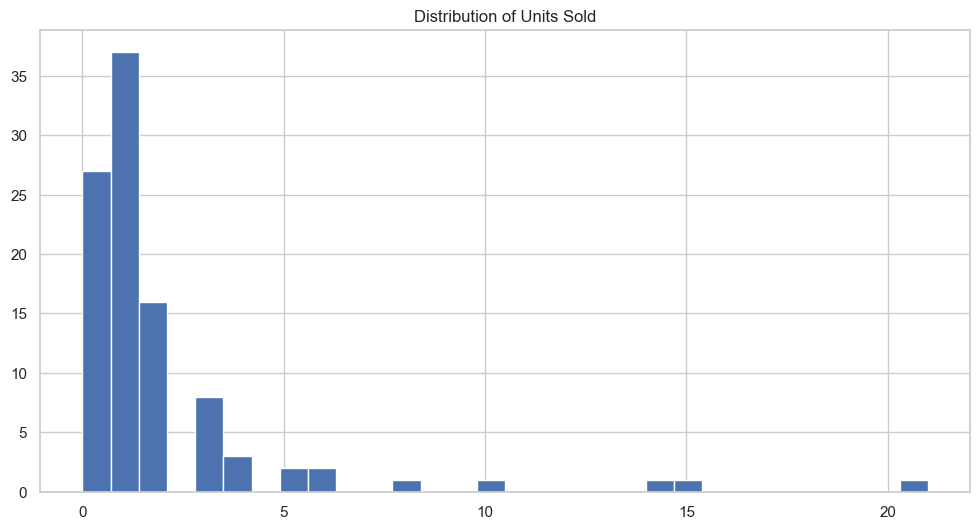

In [24]:
import matplotlib.pyplot as plt

sample_df["units_sold"].hist(bins=30)
plt.title("Distribution of Units Sold")
plt.show()

In [25]:
# Missing values
print(sample_df.isna().sum())

# Duplicates
print(sample_df.duplicated().sum())

date                       0
store_id                   0
product_id                 0
units_sold                 0
price                      0
regular_price              0
discount_pct               0
promo_flag                 0
promo_type               100
revenue                    0
starting_inventory         0
ending_inventory           0
stockout_occurred          0
city                       0
store_size                 0
category                   0
product_name               0
category_product           0
brand                      0
regular_price_product      0
cost_price                 0
is_seasonal                0
warranty_months            0
store_name                 0
city_store                 0
area                       0
region                     0
store_type                 0
store_size_store           0
year                       0
month                      0
day                        0
day_of_week                0
is_weekend                 0
is_holiday    

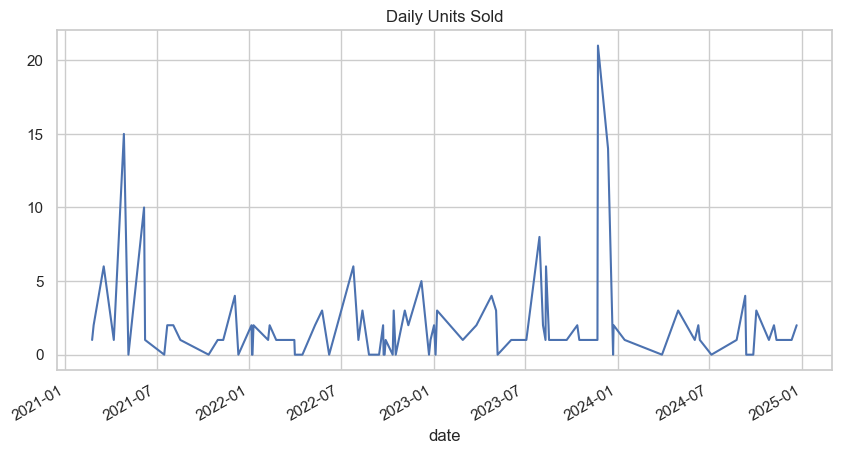

In [26]:
sample_df["date"] = pd.to_datetime(sample_df["date"])

daily_sales = sample_df.groupby("date")["units_sold"].sum()

daily_sales.plot(figsize=(10,5), title="Daily Units Sold")
plt.show()

In [27]:
# Understanding Distribution

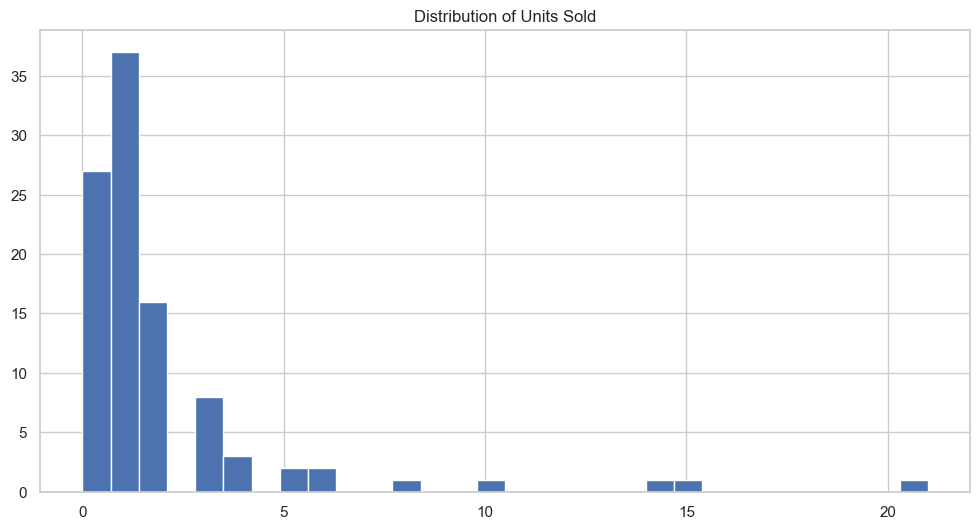

In [28]:


sample_df["units_sold"].hist(bins=30)
plt.title("Distribution of Units Sold")
plt.show()

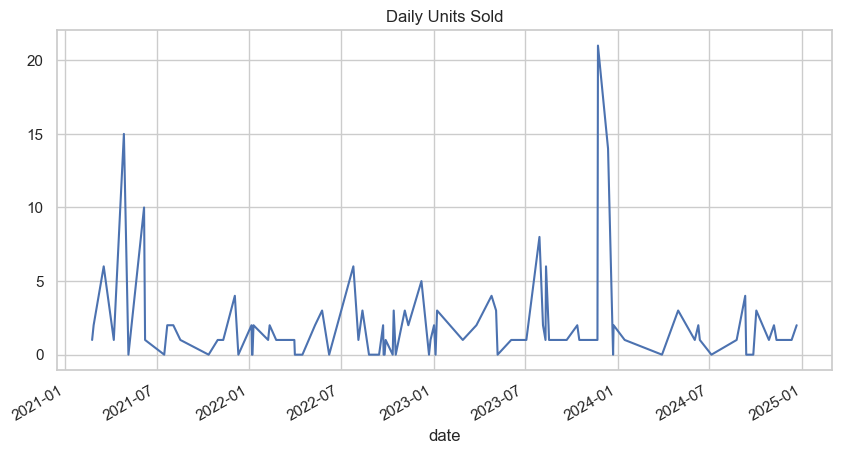

In [29]:
sample_df["date"] = pd.to_datetime(sample_df["date"])

daily_sales = sample_df.groupby("date")["units_sold"].sum()

daily_sales.plot(figsize=(10,5), title="Daily Units Sold")
plt.show()

In [30]:
# Top stores
print(sample_df.groupby("store_id")["units_sold"].sum().sort_values(ascending=False).head())

# Top products
print(sample_df.groupby("product_id")["units_sold"].sum().sort_values(ascending=False).head())

store_id
4    43
1    42
7    36
5    32
2    17
Name: units_sold, dtype: int64
product_id
1102    21
1031    16
1045    15
1054    14
1081     8
Name: units_sold, dtype: int64


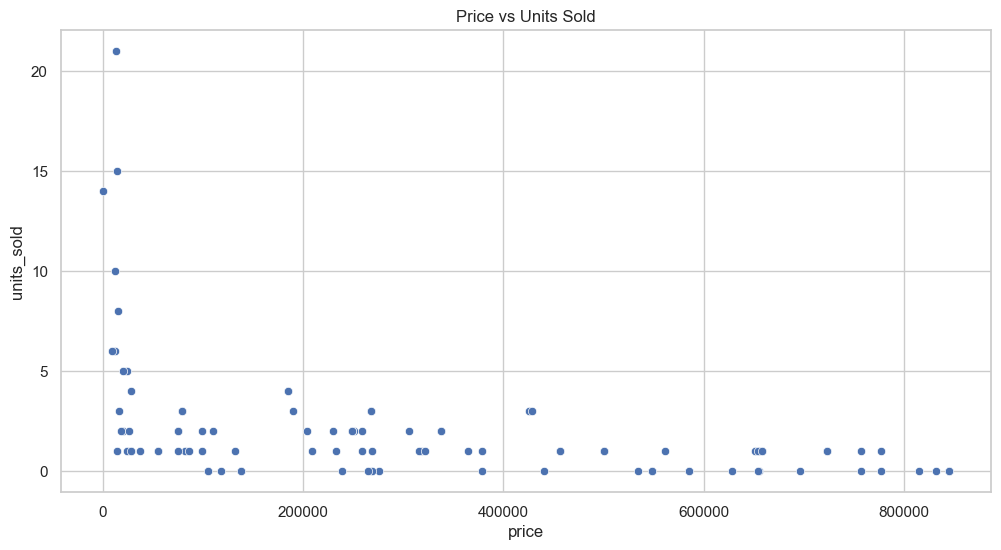

In [31]:
import seaborn as sns

sns.scatterplot(data=sample_df, x="price", y="units_sold")
plt.title("Price vs Units Sold")
plt.show()

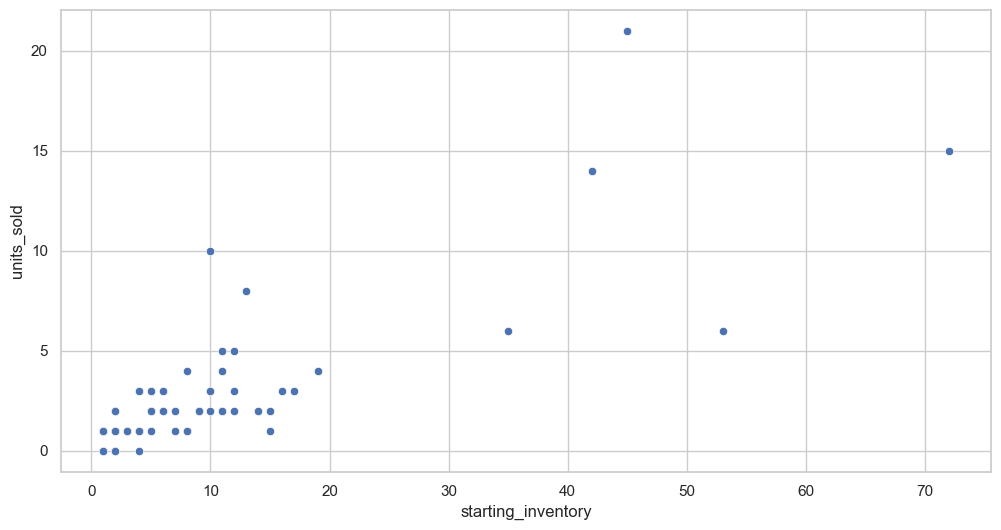

In [33]:
sample_df.groupby("promo_flag")["units_sold"].mean()

sns.scatterplot(data=sample_df, x="starting_inventory", y="units_sold")
plt.show()

In [51]:
stores.head()

,store_id,store_name,city,area,region,store_type,store_size
0,1,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large
1,2,SunnyBest Ekpoma,Ekpoma,Esan West,Edo Central,High Street,Medium
2,3,SunnyBest Auchi,Auchi,Etsako West,Edo North,High Street,Medium
3,4,SunnyBest Irrua,Irrua,Esan Central,Edo Central,Plaza,Small
4,5,SunnyBest Igueben,Igueben,Igueben,Edo Central,High Street,Small


In [52]:
inventory.head()

,date,store_id,product_id,starting_inventory,restock_qty,ending_inventory,stockout_flag
0,2021-01-01,1,1001,10,0,8,0
1,2021-01-01,1,1002,9,0,6,0
2,2021-01-01,1,1003,18,0,14,0
3,2021-01-01,1,1004,9,0,8,0
4,2021-01-01,1,1005,6,0,4,0


In [65]:
# Load all datasets

sales = pd.read_csv(f"{raw}/sunnybest_sales.csv", parse_dates=["date"])
products = pd.read_csv(f"{raw}/sunnybest_products.csv")
stores = pd.read_csv(f"{raw}/sunnybest_stores.csv")
calendar = pd.read_csv(f"{raw}/sunnybest_calendar.csv", parse_dates=["date"])
promos = pd.read_csv(f"{raw}/sunnybest_promotions.csv", parse_dates=["date"])
weather = pd.read_csv(f"{raw}/sunnybest_weather.csv", parse_dates=["date"])
inventory = pd.read_csv(f"{raw}/sunnybest_inventory.csv", parse_dates=["date"])

# 🆕 New datasets
customer_activity = pd.read_csv(f"{raw}/sunnybest_customer_activity.csv", parse_dates=["date"])
store_operations = pd.read_csv(f"{raw}/sunnybest_store_operations.csv", parse_dates=["date"])
policy_regimes = pd.read_csv(f"{raw}/sunnybest_policy_regimes.csv", parse_dates=["start_date", "end_date"])
restriction_events = pd.read_csv(f"{raw}/sunnybest_restriction_events.csv", parse_dates=["date"])

/var/folders/rt/0zxshr9s4g713_r6y5sjpqk80000gn/T/ipykernel_58080/49380473.py:3: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  sales = pd.read_csv(f"{raw}/sunnybest_sales.csv", parse_dates=["date"])


In [60]:
customer_activity.head()

,date,store_id,active_customers,new_customers,returning_customers,churn_risk_customers,net_customer_change,estimated_conversion_rate,daily_revenue
0,2021-01-01,1,371,69,302,0,0,1.437,58470174.0
1,2021-01-01,2,285,72,213,0,0,1.495,42561566.0
2,2021-01-01,3,313,56,257,0,0,1.054,49956070.0
3,2021-01-01,4,211,25,186,0,0,1.711,36997019.0
4,2021-01-01,5,292,55,237,0,0,1.110,39320692.0


In [61]:
customer_activity.shape

(10227, 9)

In [62]:
print("Hello")

Hello


In [66]:
sales

,date,store_id,product_id,units_sold,price,regular_price,discount_pct,promo_flag,promo_type,revenue,starting_inventory,restock_qty,ending_inventory,stockout_occurred,restriction_active,restriction_type,city,store_size,store_type,category
0,2021-01-01,1,1001,0,445838.0,445838,0,0,NaN,0.0,10,0,10,0,0,NaN,Benin,Large,Mall,Televisions
1,2021-01-01,1,1002,2,500410.0,500410,0,0,NaN,1000820.0,6,0,4,0,0,NaN,Benin,Large,Mall,Mobile Phones
2,2021-01-01,1,1003,4,399365.0,399365,0,0,NaN,1597460.0,16,0,12,0,0,NaN,Benin,Large,Mall,Mobile Phones
3,2021-01-01,1,1004,1,305796.0,305796,0,0,NaN,305796.0,4,0,3,0,0,NaN,Benin,Large,Mall,Mobile Phones
4,2021-01-01,1,1005,5,462752.0,462752,0,0,NaN,2313760.0,17,0,12,0,0,NaN,Benin,Large,Mall,Mobile Phones
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1606075,2026-03-27,7,1116,3,15606.0,15606,0,0,NaN,46818.0,43,0,40,0,1,Promo Suspension,Ogwa,Small,High Street,Telecom Services
1606076,2026-03-27,7,1117,5,18456.0,18456,0,0,NaN,92280.0,5,0,0,0,0,NaN,Ogwa,Small,High Street,Accessories
1606077,2026-03-27,7,1118,0,696237.0,696237,0,0,NaN,0.0,4,0,4,0,0,NaN,Ogwa,Small,High Street,Laptops & Computers
1606078,2026-03-27,7,1119,1,658153.0,658153,0,0,NaN,658153.0,5,0,4,0,0,NaN,Ogwa,Small,High Street,Laptops & Computers


In [71]:
from src.data.db_connection import run_query

query = """
SELECT *
FROM analytics.vw_daily_store_sales
LIMIT 5;
"""

df = run_query(query)
print(df)

         date store_id  total_units_sold  total_revenue
0  2021-01-01        1               578     65119411.0
1  2021-01-01        2               395     50252750.0
2  2021-01-01        3               372     46848744.0
3  2021-01-01        4               311     34267879.0
4  2021-01-01        5               333     38571312.0


/Users/bonaventure/retail-sales-forecasting-genai/src/data/db_connection.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [73]:
query = """
SELECT *
FROM core.fact_sales
WHERE date BETWEEN '2026-01-01' AND '2026-03-31'
"""

df = run_query(query)
df.head()

/Users/bonaventure/retail-sales-forecasting-genai/src/data/db_connection.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,date,store_id,product_id,units_sold,price,regular_price,discount_pct,promo_flag,promo_type,revenue,starting_inventory,restock_qty,ending_inventory,stockout_occurred,restriction_active,restriction_type
0,2026-01-01,4,1021,0,239182.0,239182.0,0.0,0,None,0.0,1,0,1,0,0,None
1,2026-01-01,4,1098,0,548345.0,548345.0,0.0,0,None,0.0,3,0,3,0,0,None
2,2026-01-01,1,1001,1,445838.0,445838.0,0.0,0,None,445838.0,3,0,2,0,0,None
3,2026-01-01,1,1002,2,500410.0,500410.0,0.0,0,None,1000820.0,8,0,6,0,0,None
4,2026-01-01,1,1003,0,399365.0,399365.0,0.0,0,None,0.0,0,0,0,1,0,None


In [74]:
query = """
SELECT
    date,
    store_id,
    SUM(units_sold) AS total_units,
    SUM(revenue) AS total_revenue
FROM core.fact_sales
WHERE date BETWEEN '2026-01-01' AND '2026-03-31'
GROUP BY date, store_id
ORDER BY date, store_id
"""

df = run_query(query)
df.head()

/Users/bonaventure/retail-sales-forecasting-genai/src/data/db_connection.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,date,store_id,total_units,total_revenue
0,2026-01-01,1,487,53904128.0
1,2026-01-01,2,367,49143326.0
2,2026-01-01,3,339,41737847.0
3,2026-01-01,4,272,31170509.0
4,2026-01-01,5,251,31189958.0


<Axes: xlabel='date'>

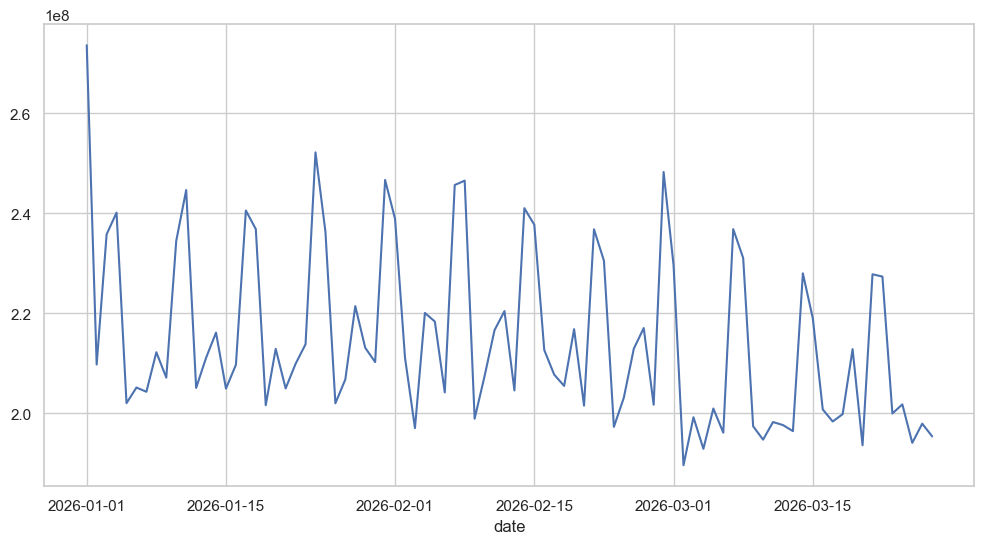

In [75]:
df.groupby("date")["total_revenue"].sum().plot()

In [76]:
import pandas as pd
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    database="sunnybest_sfs",
    user="bonaventure",
    password=""
)

query = "SELECT * FROM core.fact_sales"
df = pd.read_sql(query, conn)

print(df.head())

/var/folders/rt/0zxshr9s4g713_r6y5sjpqk80000gn/T/ipykernel_58080/4263373906.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


         date store_id  product_id  units_sold     price  regular_price  \
0  2021-01-01        1        1001           0  445838.0       445838.0   
1  2021-01-01        1        1002           2  500410.0       500410.0   
2  2021-01-01        1        1003           4  399365.0       399365.0   
3  2021-01-01        1        1004           1  305796.0       305796.0   
4  2021-01-01        1        1005           5  462752.0       462752.0   

   discount_pct  promo_flag promo_type    revenue  starting_inventory  \
0           0.0           0       None        0.0                  10   
1           0.0           0       None  1000820.0                   6   
2           0.0           0       None  1597460.0                  16   
3           0.0           0       None   305796.0                   4   
4           0.0           0       None  2313760.0                  17   

   restock_qty  ending_inventory  stockout_occurred  restriction_active  \
0            0                10   

In [77]:
df.head()

,date,store_id,product_id,units_sold,price,regular_price,discount_pct,promo_flag,promo_type,revenue,starting_inventory,restock_qty,ending_inventory,stockout_occurred,restriction_active,restriction_type
0,2021-01-01,1,1001,0,445838.0,445838.0,0.0,0,None,0.0,10,0,10,0,0,None
1,2021-01-01,1,1002,2,500410.0,500410.0,0.0,0,None,1000820.0,6,0,4,0,0,None
2,2021-01-01,1,1003,4,399365.0,399365.0,0.0,0,None,1597460.0,16,0,12,0,0,None
3,2021-01-01,1,1004,1,305796.0,305796.0,0.0,0,None,305796.0,4,0,3,0,0,None
4,2021-01-01,1,1005,5,462752.0,462752.0,0.0,0,None,2313760.0,17,0,12,0,0,None


In [78]:
cols = [
    "date",
    "store_id",
    "product_id",
    "units_sold",
    "price",
    "regular_price",
    "discount_pct",
    "promo_flag",
    "promo_type",
    "starting_inventory"
]

df = df[cols]

In [79]:
df

,date,store_id,product_id,units_sold,price,regular_price,discount_pct,promo_flag,promo_type,starting_inventory
0,2021-01-01,1,1001,0,445838.0,445838.0,0.0,0,None,10
1,2021-01-01,1,1002,2,500410.0,500410.0,0.0,0,None,6
2,2021-01-01,1,1003,4,399365.0,399365.0,0.0,0,None,16
3,2021-01-01,1,1004,1,305796.0,305796.0,0.0,0,None,4
4,2021-01-01,1,1005,5,462752.0,462752.0,0.0,0,None,17
...,...,...,...,...,...,...,...,...,...,...
1606075,2026-03-27,7,1116,3,15606.0,15606.0,0.0,0,None,43
1606076,2026-03-27,7,1117,5,18456.0,18456.0,0.0,0,None,5
1606077,2026-03-27,7,1118,0,696237.0,696237.0,0.0,0,None,4
1606078,2026-03-27,7,1119,1,658153.0,658153.0,0.0,0,None,5


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1606080 entries, 0 to 1606079
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   date                1606080 non-null  object 
 1   store_id            1606080 non-null  object 
 2   product_id          1606080 non-null  int64  
 3   units_sold          1606080 non-null  int64  
 4   price               1606080 non-null  float64
 5   regular_price       1606080 non-null  float64
 6   discount_pct        1606080 non-null  float64
 7   promo_flag          1606080 non-null  int64  
 8   promo_type          256 non-null      object 
 9   starting_inventory  1606080 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 122.5+ MB


In [81]:
df["discount_pct"].value_counts()

discount_pct
0.0     1605896
15.0         39
10.0         37
5.0          28
20.0         27
30.0         27
25.0         26
Name: count, dtype: int64

In [85]:
df.promo_type.value_counts()

promo_type
Discount          160
Bundle             37
Free Accessory     35
Price Slash        24
Name: count, dtype: int64

In [86]:
df["promo_type"] = df["promo_type"].fillna("No Promo")

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1606080 entries, 0 to 1606079
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   date                1606080 non-null  object 
 1   store_id            1606080 non-null  object 
 2   product_id          1606080 non-null  int64  
 3   units_sold          1606080 non-null  int64  
 4   price               1606080 non-null  float64
 5   regular_price       1606080 non-null  float64
 6   discount_pct        1606080 non-null  float64
 7   promo_flag          1606080 non-null  int64  
 8   promo_type          1606080 non-null  object 
 9   starting_inventory  1606080 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 122.5+ MB


In [90]:
df["date"] = pd.to_datetime(df["date"])

In [91]:
# create date_features
df["day_of_week"] = df["date"].dt.dayofweek   # 0 = Monday
df["month"] = df["date"].dt.month
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1606080 entries, 0 to 1606079
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   date                1606080 non-null  datetime64[ns]
 1   store_id            1606080 non-null  object        
 2   product_id          1606080 non-null  int64         
 3   units_sold          1606080 non-null  int64         
 4   price               1606080 non-null  float64       
 5   regular_price       1606080 non-null  float64       
 6   discount_pct        1606080 non-null  float64       
 7   promo_flag          1606080 non-null  int64         
 8   promo_type          1606080 non-null  object        
 9   starting_inventory  1606080 non-null  int64         
 10  day_of_week         1606080 non-null  int32         
 11  month               1606080 non-null  int32         
 12  is_weekend          1606080 non-null  int64         
dtypes: datetime6

In [93]:
df.head()

,date,store_id,product_id,units_sold,price,regular_price,discount_pct,promo_flag,promo_type,starting_inventory,day_of_week,month,is_weekend
0,2021-01-01,1,1001,0,445838.0,445838.0,0.0,0,No Promo,10,4,1,0
1,2021-01-01,1,1002,2,500410.0,500410.0,0.0,0,No Promo,6,4,1,0
2,2021-01-01,1,1003,4,399365.0,399365.0,0.0,0,No Promo,16,4,1,0
3,2021-01-01,1,1004,1,305796.0,305796.0,0.0,0,No Promo,4,4,1,0
4,2021-01-01,1,1005,5,462752.0,462752.0,0.0,0,No Promo,17,4,1,0


In [94]:
df = pd.get_dummies(df, columns=["store_id", "product_id", "promo_type"], drop_first=True)

In [95]:
df.head()

,date,units_sold,price,regular_price,discount_pct,promo_flag,starting_inventory,day_of_week,month,is_weekend,store_id_2,store_id_3,store_id_4,store_id_5,store_id_6,store_id_7,product_id_1002,product_id_1003,product_id_1004,product_id_1005,product_id_1006,product_id_1007,product_id_1008,product_id_1009,product_id_1010,product_id_1011,product_id_1012,product_id_1013,product_id_1014,product_id_1015,product_id_1016,product_id_1017,product_id_1018,product_id_1019,product_id_1020,product_id_1021,product_id_1022,product_id_1023,product_id_1024,product_id_1025,product_id_1026,product_id_1027,product_id_1028,product_id_1029,product_id_1030,product_id_1031,product_id_1032,product_id_1033,product_id_1034,product_id_1035,product_id_1036,product_id_1037,product_id_1038,product_id_1039,product_id_1040,product_id_1041,product_id_1042,product_id_1043,product_id_1044,product_id_1045,product_id_1046,product_id_1047,product_id_1048,product_id_1049,product_id_1050,product_id_1051,product_id_1052,product_id_1053,product_id_1054,product_id_1055,product_id_1056,product_id_1057,product_id_1058,product_id_1059,product_id_1060,product_id_1061,product_id_1062,product_id_1063,product_id_1064,product_id_1065,product_id_1066,product_id_1067,product_id_1068,product_id_1069,product_id_1070,product_id_1071,product_id_1072,product_id_1073,product_id_1074,product_id_1075,product_id_1076,product_id_1077,product_id_1078,product_id_1079,product_id_1080,product_id_1081,product_id_1082,product_id_1083,product_id_1084,product_id_1085,product_id_1086,product_id_1087,product_id_1088,product_id_1089,product_id_1090,product_id_1091,product_id_1092,product_id_1093,product_id_1094,product_id_1095,product_id_1096,product_id_1097,product_id_1098,product_id_1099,product_id_1100,product_id_1101,product_id_1102,product_id_1103,product_id_1104,product_id_1105,product_id_1106,product_id_1107,product_id_1108,product_id_1109,product_id_1110,product_id_1111,product_id_1112,product_id_1113,product_id_1114,product_id_1115,product_id_1116,product_id_1117,product_id_1118,product_id_1119,product_id_1120,promo_type_Discount,promo_type_Free Accessory,promo_type_No Promo,promo_type_Price Slash
0,2021-01-01,0,445838.0,445838.0,0.0,0,10,4,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,2021-01-01,2,500410.0,500410.0,0.0,0,6,4,1,0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,2021-01-01,4,399365.0,399365.0,0.0,0,16,4,1,0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,F

In [96]:
X = df.drop(columns=["units_sold", "date"])
y = df["units_sold"]

In [98]:
X

,price,regular_price,discount_pct,promo_flag,starting_inventory,day_of_week,month,is_weekend,store_id_2,store_id_3,store_id_4,store_id_5,store_id_6,store_id_7,product_id_1002,product_id_1003,product_id_1004,product_id_1005,product_id_1006,product_id_1007,product_id_1008,product_id_1009,product_id_1010,product_id_1011,product_id_1012,product_id_1013,product_id_1014,product_id_1015,product_id_1016,product_id_1017,product_id_1018,product_id_1019,product_id_1020,product_id_1021,product_id_1022,product_id_1023,product_id_1024,product_id_1025,product_id_1026,product_id_1027,product_id_1028,product_id_1029,product_id_1030,product_id_1031,product_id_1032,product_id_1033,product_id_1034,product_id_1035,product_id_1036,product_id_1037,product_id_1038,product_id_1039,product_id_1040,product_id_1041,product_id_1042,product_id_1043,product_id_1044,product_id_1045,product_id_1046,product_id_1047,product_id_1048,product_id_1049,product_id_1050,product_id_1051,product_id_1052,product_id_1053,product_id_1054,product_id_1055,product_id_1056,product_id_1057,product_id_1058,product_id_1059,product_id_1060,product_id_1061,product_id_1062,product_id_1063,product_id_1064,product_id_1065,product_id_1066,product_id_1067,product_id_1068,product_id_1069,product_id_1070,product_id_1071,product_id_1072,product_id_1073,product_id_1074,product_id_1075,product_id_1076,product_id_1077,product_id_1078,product_id_1079,product_id_1080,product_id_1081,product_id_1082,product_id_1083,product_id_1084,product_id_1085,product_id_1086,product_id_1087,product_id_1088,product_id_1089,product_id_1090,product_id_1091,product_id_1092,product_id_1093,product_id_1094,product_id_1095,product_id_1096,product_id_1097,product_id_1098,product_id_1099,product_id_1100,product_id_1101,product_id_1102,product_id_1103,product_id_1104,product_id_1105,product_id_1106,product_id_1107,product_id_1108,product_id_1109,product_id_1110,product_id_1111,product_id_1112,product_id_1113,product_id_1114,product_id_1115,product_id_1116,product_id_1117,product_id_1118,product_id_1119,product_id_1120,promo_type_Discount,promo_type_Free Accessory,promo_type_No Promo,promo_type_Price Slash
0,445838.0,445838.0,0.0,0,10,4,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,500410.0,500410.0,0.0,0,6,4,1,0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,399365.0,399365.0,0.0,0,16,4,1,0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fa

In [99]:
df = df.sort_values("date")

split_date = df["date"].quantile(0.8)

train = df[df["date"] <= split_date]
test = df[df["date"] > split_date]

X_train = train.drop(columns=["units_sold", "date"])
y_train = train["units_sold"]

X_test = test.drop(columns=["units_sold", "date"])
y_test = test["units_sold"]

In [100]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [101]:
y_pred = model.predict(X_test)

In [102]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 0.6974964833827265


In [103]:
# Check if I have a good MAE

In [104]:
df["units_sold"].mean()

np.float64(2.357805339709105)

## Adding Lag features Version A

In [134]:
import pandas as pd
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    database="sunnybest_sfs",
    user="bonaventure",
    password=""
)

query = "SELECT * FROM core.fact_sales"
df = pd.read_sql(query, conn)
conn.close()

/var/folders/rt/0zxshr9s4g713_r6y5sjpqk80000gn/T/ipykernel_58080/2898319778.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_v1 = pd.read_sql(query, conn)


In [108]:
df

,date,store_id,product_id,units_sold,price,regular_price,discount_pct,promo_flag,promo_type,starting_inventory
0,2021-01-01,1,1001,0,445838.0,445838.0,0.0,0,No Promo,10
1,2021-01-01,1,1002,2,500410.0,500410.0,0.0,0,No Promo,6
2,2021-01-01,1,1003,4,399365.0,399365.0,0.0,0,No Promo,16
3,2021-01-01,1,1004,1,305796.0,305796.0,0.0,0,No Promo,4
4,2021-01-01,1,1005,5,462752.0,462752.0,0.0,0,No Promo,17
...,...,...,...,...,...,...,...,...,...,...
1606075,2026-03-27,7,1116,3,15606.0,15606.0,0.0,0,No Promo,43
1606076,2026-03-27,7,1117,5,18456.0,18456.0,0.0,0,No Promo,5
1606077,2026-03-27,7,1118,0,696237.0,696237.0,0.0,0,No Promo,4
1606078,2026-03-27,7,1119,1,658153.0,658153.0,0.0,0,No Promo,5


In [109]:
df = df.sort_values(["store_id", "product_id", "date"]).copy()

In [110]:
df

,date,store_id,product_id,units_sold,price,regular_price,discount_pct,promo_flag,promo_type,starting_inventory
0,2021-01-01,1,1001,0,445838.0,445838.0,0.0,0,No Promo,10
841,2021-01-02,1,1001,1,445838.0,445838.0,0.0,0,No Promo,10
1682,2021-01-03,1,1001,1,445838.0,445838.0,0.0,0,No Promo,9
2522,2021-01-04,1,1001,1,445838.0,445838.0,0.0,0,No Promo,8
3362,2021-01-05,1,1001,1,445838.0,445838.0,0.0,0,No Promo,7
...,...,...,...,...,...,...,...,...,...,...
1602719,2026-03-23,7,1120,0,740053.0,740053.0,0.0,0,No Promo,4
1603559,2026-03-24,7,1120,0,740053.0,740053.0,0.0,0,No Promo,4
1604399,2026-03-25,7,1120,0,740053.0,740053.0,0.0,0,No Promo,4
1605240,2026-03-26,7,1120,0,740053.0,740053.0,0.0,0,No Promo,4


In [111]:
group_cols = ["store_id", "product_id"]

df["lag_1"] = df.groupby(group_cols)["units_sold"].shift(1)
df["lag_7"] = df.groupby(group_cols)["units_sold"].shift(7)

df["rolling_mean_7"] = (
    df.groupby(group_cols)["units_sold"]
      .shift(1)
      .rolling(window=7)
      .mean()
)

In [112]:
df[[
    "date", "store_id", "product_id", "units_sold",
    "lag_1", "lag_7", "rolling_mean_7"
]].head(15)

,date,store_id,product_id,units_sold,lag_1,lag_7,rolling_mean_7
0,2021-01-01,1,1001,0,NaN,NaN,NaN
841,2021-01-02,1,1001,1,0.0,NaN,NaN
1682,2021-01-03,1,1001,1,1.0,NaN,NaN
2522,2021-01-04,1,1001,1,1.0,NaN,NaN
3362,2021-01-05,1,1001,1,1.0,NaN,NaN
4202,2021-01-06,1,1001,1,1.0,NaN,NaN
5042,2021-01-07,1,1001,1,1.0,NaN,NaN
5884,2021-01-08,1,1001,1,1.0,0.0,0.857143
6723,2021-01-09,1,1001,1,1.0,1.0,1.000000
7562,2021-01-10,1,1001,1,1.0,1.0,1.000000


In [113]:
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["day_of_month"] = df["date"].dt.day
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

In [114]:
df = pd.get_dummies(
    df,
    columns=["store_id", "product_id", "promo_type"],
    drop_first=True
)

In [115]:
df = df.sort_values("date").copy()

split_date = df["date"].quantile(0.8)

train = df[df["date"] <= split_date].copy()
test = df[df["date"] > split_date].copy()

X_train = train.drop(columns=["units_sold", "date"])
y_train = train["units_sold"]

X_test = test.drop(columns=["units_sold", "date"])
y_test = test["units_sold"]

In [116]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
wape = np.sum(np.abs(y_test - y_pred)) / np.sum(y_test)

print("Mean Units Sold:", y_test.mean())
print("MAE:", mae)
print("WAPE:", wape)

Mean Units Sold: 2.356927823485415
MAE: 0.6696770132136625
WAPE: 0.2841313198226609


## Version B

In [136]:
import pandas as pd

# Create DataFrame of feature importance
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(by="importance", ascending=False)

# Show top 20
print(feature_importance.head(20))

                feature  importance
7        rolling_mean_7    0.784307
4    starting_inventory    0.113555
5                 lag_1    0.016772
6                 lag_7    0.015851
10         day_of_month    0.015353
11         week_of_year    0.011997
9                 month    0.009406
8           day_of_week    0.007704
0                 price    0.003121
1         regular_price    0.003041
12           is_weekend    0.002214
48      product_id_1031    0.001669
14           store_id_3    0.001614
13           store_id_2    0.001470
16           store_id_5    0.001392
17           store_id_6    0.001174
133     product_id_1116    0.001114
15           store_id_4    0.001079
62      product_id_1045    0.001076
18           store_id_7    0.001038


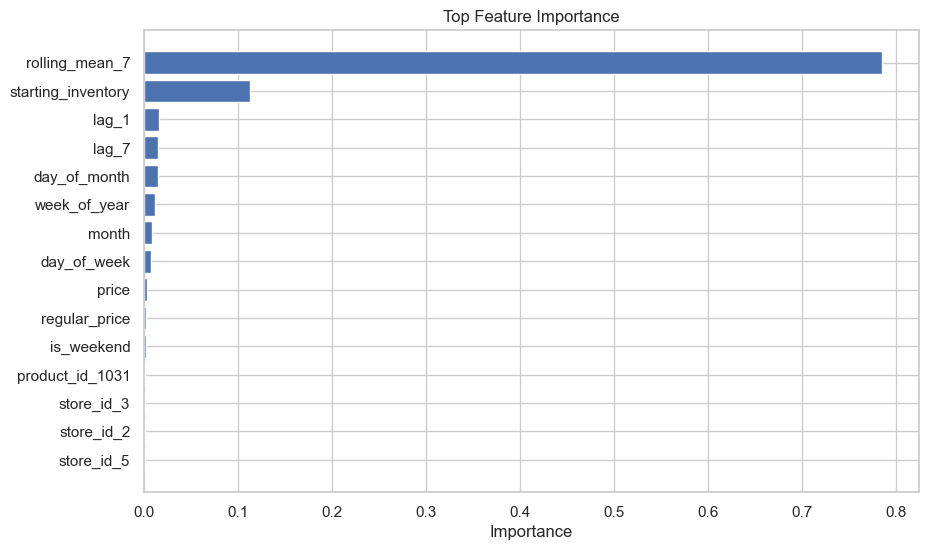

In [137]:
import matplotlib.pyplot as plt

top_n = 15

fi = feature_importance.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(fi["feature"], fi["importance"])
plt.gca().invert_yaxis()
plt.title("Top Feature Importance")
plt.xlabel("Importance")
plt.show()

In [157]:
import pandas as pd
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    database="sunnybest_sfs",
    user="bonaventure",
    password=""
)

query = "SELECT * FROM core.fact_sales"
df_v2 = pd.read_sql(query, conn)
conn.close()

/var/folders/rt/0zxshr9s4g713_r6y5sjpqk80000gn/T/ipykernel_58080/2612180151.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_v2 = pd.read_sql(query, conn)


In [158]:
df_v2.columns

Index(['date', 'store_id', 'product_id', 'units_sold', 'price',
       'regular_price', 'discount_pct', 'promo_flag', 'promo_type', 'revenue',
       'starting_inventory', 'restock_qty', 'ending_inventory',
       'stockout_occurred', 'restriction_active', 'restriction_type'],
      dtype='object')

In [159]:
cols = [
    "date",
    "store_id",
    "product_id",
    "units_sold",
    "price",
    "regular_price",
    "discount_pct",
    "promo_flag",
    "promo_type",
    "starting_inventory"
]

df_v2 = df_v2[cols].copy()

In [160]:
df_v2["date"] = pd.to_datetime(df_v2["date"], errors="coerce")

df_v2 = df_v2.dropna(subset=["date", "store_id", "product_id", "units_sold"])

df_v2["price"] = pd.to_numeric(df_v2["price"], errors="coerce").fillna(0)
df_v2["regular_price"] = pd.to_numeric(df_v2["regular_price"], errors="coerce").fillna(0)
df_v2["discount_pct"] = pd.to_numeric(df_v2["discount_pct"], errors="coerce").fillna(0)
df_v2["promo_flag"] = pd.to_numeric(df_v2["promo_flag"], errors="coerce").fillna(0).astype(int)
df_v2["units_sold"] = pd.to_numeric(df_v2["units_sold"], errors="coerce")

df_v2["promo_type"] = df_v2["promo_type"].fillna("No Promo")
df_v2.loc[df_v2["promo_flag"] == 0, "promo_type"] = "No Promo"

df_v2 = df_v2.dropna(subset=["units_sold"])
df_v2 = df_v2[df_v2["units_sold"] >= 0].copy()

In [161]:
df_v2 = df_v2.sort_values(["store_id", "product_id", "date"]).copy()

In [162]:
group_cols = ["store_id", "product_id"]

df_v2["lag_1"] = df_v2.groupby(group_cols)["units_sold"].shift(1)
df_v2["lag_7"] = df_v2.groupby(group_cols)["units_sold"].shift(7)
df_v2["lag_14"] = df_v2.groupby(group_cols)["units_sold"].shift(14)

In [163]:
df_v2["rolling_mean_7"] = (
    df_v2.groupby(group_cols)["units_sold"]
    .shift(1)
    .rolling(7)
    .mean()
)

df_v2["rolling_mean_14"] = (
    df_v2.groupby(group_cols)["units_sold"]
    .shift(1)
    .rolling(14)
    .mean()
)

df_v2["rolling_std_7"] = (
    df_v2.groupby(group_cols)["units_sold"]
    .shift(1)
    .rolling(7)
    .std()
)

In [164]:
df_v2 = df_v2.dropna(subset=[
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_std_7"
]).copy()

In [165]:
df_v2["day_of_week"] = df_v2["date"].dt.dayofweek
df_v2["month"] = df_v2["date"].dt.month
df_v2["day_of_month"] = df_v2["date"].dt.day
df_v2["week_of_year"] = df_v2["date"].dt.isocalendar().week.astype(int)
df_v2["is_weekend"] = df_v2["day_of_week"].isin([5, 6]).astype(int)

In [166]:
df_v2 = pd.get_dummies(
    df_v2,
    columns=["store_id", "product_id", "promo_type"],
    drop_first=True
)

In [167]:
df_v2 = df_v2.sort_values("date").copy()

split_date = df_v2["date"].quantile(0.8)

train = df_v2[df_v2["date"] <= split_date].copy()
test = df_v2[df_v2["date"] > split_date].copy()

X_train = train.drop(columns=["units_sold", "date"])
y_train = train["units_sold"]

X_test = test.drop(columns=["units_sold", "date"])
y_test = test["units_sold"]

In [168]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

model_v2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_v2.fit(X_train, y_train)

y_pred = model_v2.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
wape = np.sum(np.abs(y_test - y_pred)) / np.sum(y_test)

print("Mean Units:", y_test.mean())
print("MAE:", mae)
print("WAPE:", wape)

Mean Units: 2.3574255559743684
MAE: 0.662151055408971
WAPE: 0.2808788823599952


In [169]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_v2.feature_importances_
}).sort_values(by="importance", ascending=False)

print(feature_importance.head(15))

               feature  importance
9      rolling_mean_14    0.793418
4   starting_inventory    0.102355
10       rolling_std_7    0.017264
8       rolling_mean_7    0.011010
13        day_of_month    0.010319
7               lag_14    0.009492
5                lag_1    0.009155
6                lag_7    0.008932
14        week_of_year    0.008326
12               month    0.007932
11         day_of_week    0.005935
15          is_weekend    0.002104
0                price    0.001976
1        regular_price    0.001938
51     product_id_1031    0.000995


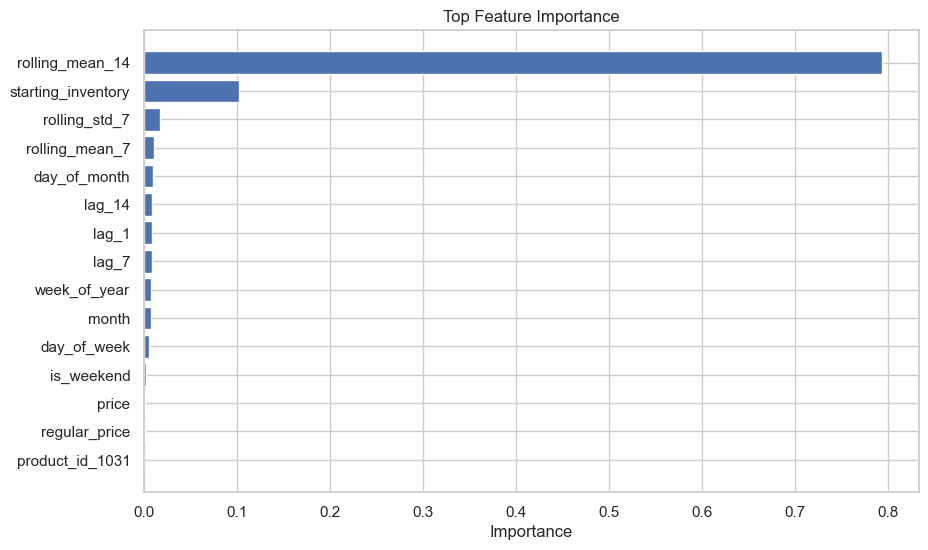

In [170]:
import matplotlib.pyplot as plt



fi = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(fi["feature"], fi["importance"])
plt.gca().invert_yaxis()
plt.title("Top Feature Importance")
plt.xlabel("Importance")
plt.show()

In [171]:
from xgboost import XGBRegressor

model_v3 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model_v3.fit(X_train, y_train)

y_pred = model_v3.predict(X_test)

In [172]:
from sklearn.metrics import mean_absolute_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
wape = np.sum(np.abs(y_test - y_pred)) / np.sum(y_test)

print("MAE:", mae)
print("WAPE:", wape)

MAE: 0.6662370562553406
WAPE: 0.2826121313593802


In [173]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

model_v3 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model_v3.fit(X_train, y_train)

y_pred = model_v3.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
mae = mean_absolute_error(y_test, y_pred)

wape = np.sum(np.abs(y_test - y_pred)) / np.sum(y_test)

print("Model Performance")
print("------------------------")
print("Mean Units:", y_test.mean())
print("MAE:", mae)
print("WAPE:", wape)

Model Performance
------------------------
Mean Units: 2.3574255559743684
MAE: 0.6662370562553406
WAPE: 0.2826121313593802


In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

models = {
    "LinearRegression": LinearRegression(),
    
    "RandomForest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3
    ),
    
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    wape = np.sum(np.abs(y_test - y_pred)) / np.sum(y_test)
    
    results.append({
        "model": name,
        "MAE": mae,
        "WAPE": wape
    })

# Convert to DataFrame
results_df = pd.DataFrame(results).sort_values(by="MAE")

print("\nModel Comparison:")
print(results_df)


Training LinearRegression...

Training RandomForest...
